# Phase 1 — Modélisation de la Roquette
## Simulateur Iron Dome — PFA ENSTAB
### Skander Frini & Yessmine Abbes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

In [2]:
class Rocket:

    
    def __init__(self, v0, angle_deg, x0=0, y0=0):
        
        self.v0 = v0
        self.angle = np.radians(angle_deg)  
        self.x0 = x0
        self.y0 = y0
        self.g = 9.81  
        
        # vitesse initiale
        self.vx0 = v0 * np.cos(self.angle) 
        self.vy0 = v0 * np.sin(self.angle)  
    
    def temps_de_vol(self):
        """Calcule la durée totale du vol jusqu'à l'impact au sol."""
        return (2 * self.vy0) / self.g
    
    def portee(self):
        """Calcule la distance horizontale totale (portée)."""
        return (self.v0**2 * np.sin(2 * self.angle)) / self.g
    
    def hauteur_max(self):
        """Calcule l'altitude maximale atteinte."""
        return (self.vy0**2) / (2 * self.g)
    
    def position(self, t):
        """
        Calcule la position (x, y) à l'instant t.
        Retourne None si la roquette a déjà touché le sol.
        """
        x = self.x0 + self.vx0 * t
        y = self.y0 + self.vy0 * t - 0.5 * self.g * t**2
        
        # La roquette ne va pas sous le sol
        if y < 0:
            return None
        return x, y
    
    def trajectoire_complete(self, dt=0.1):
        """
        Génère tous les points de la trajectoire.
        dt = pas de temps en secondes (plus petit = plus précis)
        """
        T = self.temps_de_vol()
        
        # Créer un tableau de temps de 0 à T par pas de dt
        t_array = np.arange(0, T, dt)
        
        # Calculer x et y pour chaque instant
        x_array = self.x0 + self.vx0 * t_array
        y_array = self.y0 + self.vy0 * t_array - 0.5 * self.g * t_array**2
        
        # Garder uniquement les points où y >= 0
        masque = y_array >= 0
        
        return t_array[masque], x_array[masque], y_array[masque]
    
    def vitesse(self, t):
        """Calcule la vitesse (vx, vy) à l'instant t."""
        vx = self.vx0  # constante
        vy = self.vy0 - self.g * t
        return vx, vy
    
    def infos(self):
        """Affiche un résumé des caractéristiques de la roquette."""
        print(f"=== Roquette ===")
        print(f"Vitesse initiale  : {self.v0} m/s")
        print(f"Angle de tir      : {np.degrees(self.angle):.1f}°")
        print(f"Vitesse X initiale: {self.vx0:.2f} m/s")
        print(f"Vitesse Y initiale: {self.vy0:.2f} m/s")
        print(f"Temps de vol      : {self.temps_de_vol():.2f} s")
        print(f"Portée            : {self.portee():.2f} m")
        print(f"Hauteur maximale  : {self.hauteur_max():.2f} m")

In [3]:
# Créer une roquette
r = Rocket(v0=200, angle_deg=45)

# Afficher ses informations
r.infos()

=== Roquette ===
Vitesse initiale  : 200 m/s
Angle de tir      : 45.0°
Vitesse X initiale: 141.42 m/s
Vitesse Y initiale: 141.42 m/s
Temps de vol      : 28.83 s
Portée            : 4077.47 m
Hauteur maximale  : 1019.37 m


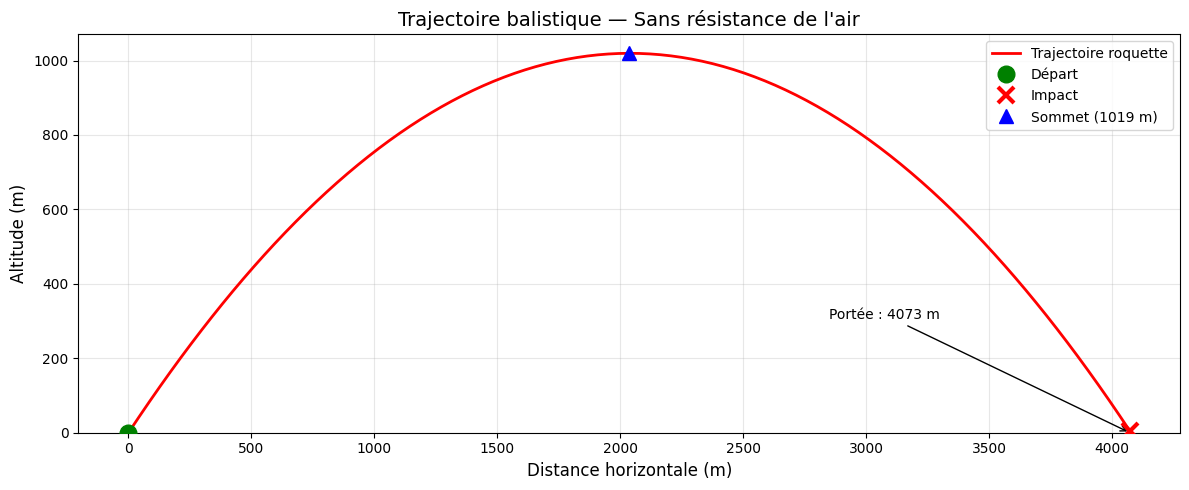

In [4]:
# Récupérer les points de la trajectoire
t, x, y = r.trajectoire_complete(dt=0.1)

# Créer le graphique
fig, ax = plt.subplots(figsize=(12, 5))

# Tracer la trajectoire
ax.plot(x, y, 'r-', linewidth=2, label='Trajectoire roquette')

# Marquer le point de départ
ax.plot(x[0], y[0], 'go', markersize=12, label='Départ', zorder=5)

# Marquer le point d'impact
ax.plot(x[-1], y[-1], 'rx', markersize=12, 
        markeredgewidth=3, label='Impact', zorder=5)

# Marquer le sommet
idx_max = np.argmax(y)
ax.plot(x[idx_max], y[idx_max], 'b^', markersize=10, 
        label=f'Sommet ({y[idx_max]:.0f} m)', zorder=5)

# Mise en forme
ax.set_xlabel('Distance horizontale (m)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title('Trajectoire balistique — Sans résistance de l\'air', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Annoter les valeurs importantes
ax.annotate(f'Portée : {x[-1]:.0f} m', 
            xy=(x[-1], 0), xytext=(x[-1]*0.7, y[idx_max]*0.3),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

plt.tight_layout()
plt.savefig('trajectoire_sans_drag.png', dpi=150)
plt.show()

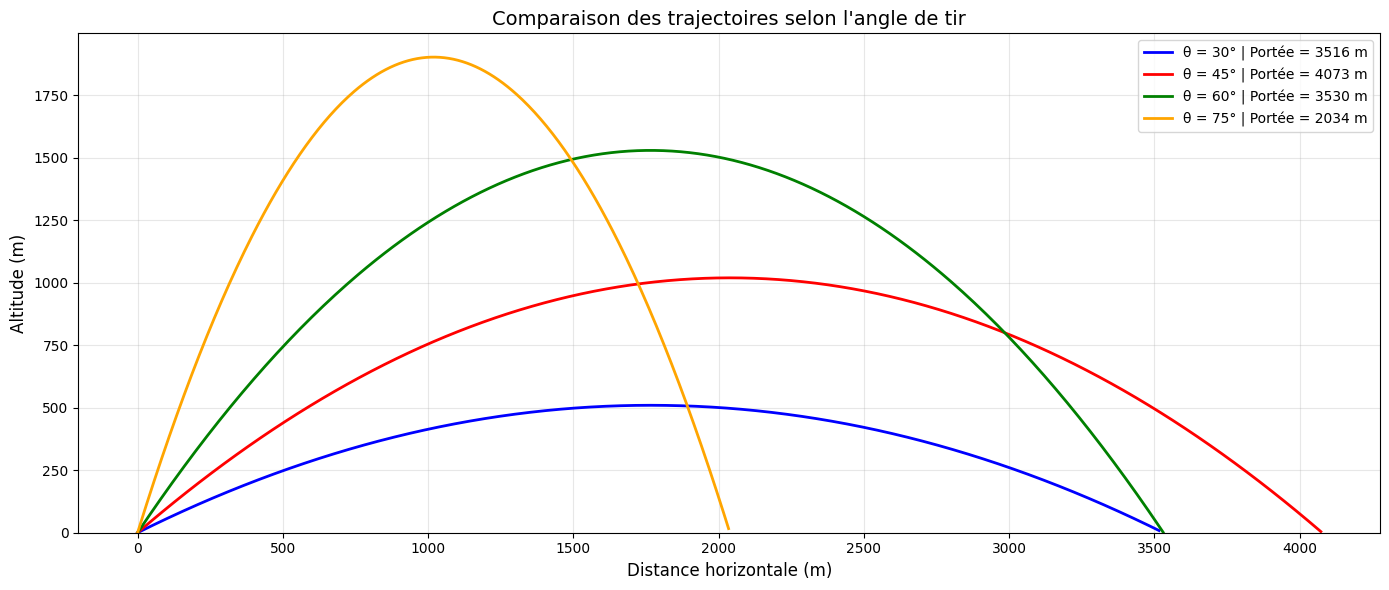

In [5]:
angles = [30, 45, 60, 75]
couleurs = ['blue', 'red', 'green', 'orange']

fig, ax = plt.subplots(figsize=(14, 6))

for angle, couleur in zip(angles, couleurs):
    r = Rocket(v0=200, angle_deg=angle)
    t, x, y = r.trajectoire_complete(dt=0.1)
    ax.plot(x, y, color=couleur, linewidth=2,
            label=f'θ = {angle}° | Portée = {x[-1]:.0f} m')

ax.set_xlabel('Distance horizontale (m)', fontsize=12)
ax.set_ylabel('Altitude (m)', fontsize=12)
ax.set_title('Comparaison des trajectoires selon l\'angle de tir', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('comparaison_angles.png', dpi=150)
plt.show()

In [6]:
class RocketWithDrag:
    """
    Roquette avec résistance de l'air.
    Utilise la méthode d'Euler pour intégration numérique.
    """
    
    def __init__(self, v0, angle_deg, masse=100, 
                 Cd=0.3, A=0.05, x0=0, y0=0):
        self.v0 = v0
        self.angle = np.radians(angle_deg)
        self.masse = masse
        self.Cd = Cd
        self.A = A
        self.x0 = x0
        self.y0 = y0
        
        self.g = 9.81
        self.rho = 1.225
        
        self.vx0 = v0 * np.cos(self.angle)
        self.vy0 = v0 * np.sin(self.angle)
    
    def _force_drag(self, vx, vy):
        v = np.sqrt(vx**2 + vy**2)
        if v == 0:
            return 0, 0
        F_drag = 0.5 * self.rho * self.Cd * self.A * v**2
        F_drag_x = -F_drag * (vx / v)
        F_drag_y = -F_drag * (vy / v)
        return F_drag_x, F_drag_y
    
    def trajectoire_euler(self, dt=0.01):
        t_list, x_list, y_list = [], [], []
        vx_list, vy_list = [], []
        
        t = 0
        x, y = self.x0, self.y0
        vx, vy = self.vx0, self.vy0
        
        while True:
            t_list.append(t)
            x_list.append(x)
            y_list.append(y)
            vx_list.append(vx)
            vy_list.append(vy)
            
            Fdx, Fdy = self._force_drag(vx, vy)
            ax = Fdx / self.masse
            ay = -self.g + Fdy / self.masse
            
            new_vx = vx + ax * dt
            new_vy = vy + ay * dt
            new_x = x + vx * dt
            new_y = y + vy * dt
            
            # Si y passe en dessous de 0 → interpoler
            if new_y < 0 and y >= 0:
                frac = y / (y - new_y)
                t_list.append(t + frac * dt)
                x_list.append(x + frac * (new_x - x))
                y_list.append(0.0)
                vx_list.append(vx + frac * (new_vx - vx))
                vy_list.append(vy + frac * (new_vy - vy))
                break
            
            vx, vy = new_vx, new_vy
            x, y = new_x, new_y
            t += dt
        
        return (np.array(t_list), np.array(x_list), 
                np.array(y_list), np.array(vx_list), np.array(vy_list))

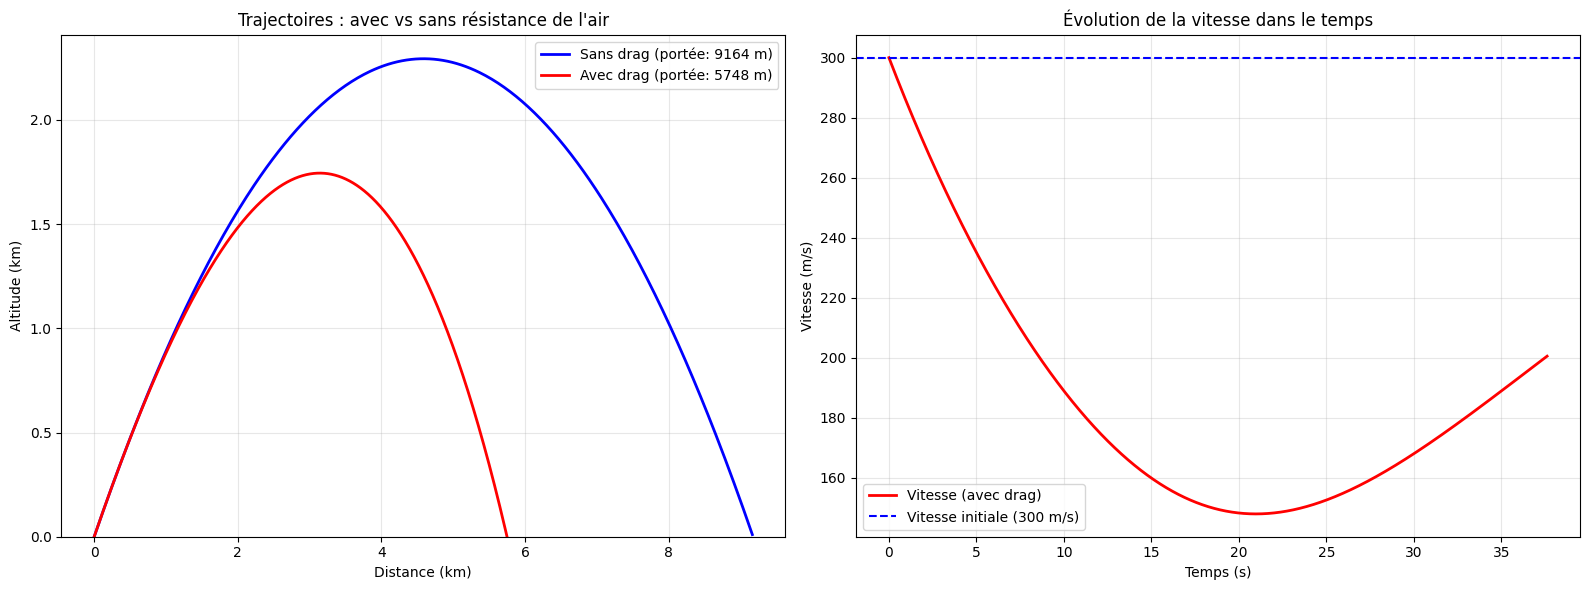


Portée sans drag : 9164 m
Portée avec drag : 5748 m
Perte de portée  : 37.3% à cause du drag


In [7]:

v0 = 300
angle = 45

# Sans drag
r_simple = Rocket(v0=v0, angle_deg=angle)
t1, x1, y1 = r_simple.trajectoire_complete(dt=0.1)

# Avec drag
r_drag = RocketWithDrag(v0=v0, angle_deg=angle, masse=100, Cd=0.3, A=0.05)
t2, x2, y2, vx2, vy2 = r_drag.trajectoire_euler(dt=0.01)


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# graphe 1 : trajectoire
ax1 = axes[0]
ax1.plot(x1/1000, y1/1000, 'b-', linewidth=2, 
         label=f'Sans drag (portée: {x1[-1]:.0f} m)')
ax1.plot(x2/1000, y2/1000, 'r-', linewidth=2,
         label=f'Avec drag (portée: {x2[-1]:.0f} m)')
ax1.set_xlabel('Distance (km)')
ax1.set_ylabel('Altitude (km)')
ax1.set_title('Trajectoires : avec vs sans résistance de l\'air')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# graphe 2 : vitesse tt 
ax2 = axes[1]
v_total = np.sqrt(vx2**2 + vy2**2)
ax2.plot(t2, v_total, 'r-', linewidth=2, label='Vitesse (avec drag)')
ax2.axhline(y=v0, color='b', linestyle='--', 
            label=f'Vitesse initiale ({v0} m/s)')
ax2.set_xlabel('Temps (s)')
ax2.set_ylabel('Vitesse (m/s)')
ax2.set_title('Évolution de la vitesse dans le temps')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comparaison_drag.png', dpi=150)
plt.show()

# diff
perte_portee = (x1[-1] - x2[-1]) / x1[-1] * 100
print(f"\nPortée sans drag : {x1[-1]:.0f} m")
print(f"Portée avec drag : {x2[-1]:.0f} m")
print(f"Perte de portée  : {perte_portee:.1f}% à cause du drag")

In [8]:
class RocketRK4(RocketWithDrag):
    
    
    def _derivees(self, state):
        x, y, vx, vy = state
        Fdx, Fdy = self._force_drag(vx, vy)
        ax = Fdx / self.masse
        ay = -self.g + Fdy / self.masse
        return np.array([vx, vy, ax, ay])
    
    def trajectoire_rk4(self, dt=0.1):
        t_list, x_list, y_list = [], [], []
        
        t = 0
        state = np.array([self.x0, self.y0, self.vx0, self.vy0])
        
        while True:
            t_list.append(t)
            x_list.append(state[0])
            y_list.append(state[1])
            
            k1 = self._derivees(state)
            k2 = self._derivees(state + dt/2 * k1)
            k3 = self._derivees(state + dt/2 * k2)
            k4 = self._derivees(state + dt * k3)
            
            new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
            t += dt
            
            # Si y passe en dessous de 0 → interpoler
            if new_state[1] < 0 and state[1] >= 0:
                frac = state[1] / (state[1] - new_state[1])
                x_impact = state[0] + frac * (new_state[0] - state[0])
                t_impact = t - dt + frac * dt
                
                t_list.append(t_impact)
                x_list.append(x_impact)
                y_list.append(0.0)
                break
            
            state = new_state
        
        return np.array(t_list), np.array(x_list), np.array(y_list)

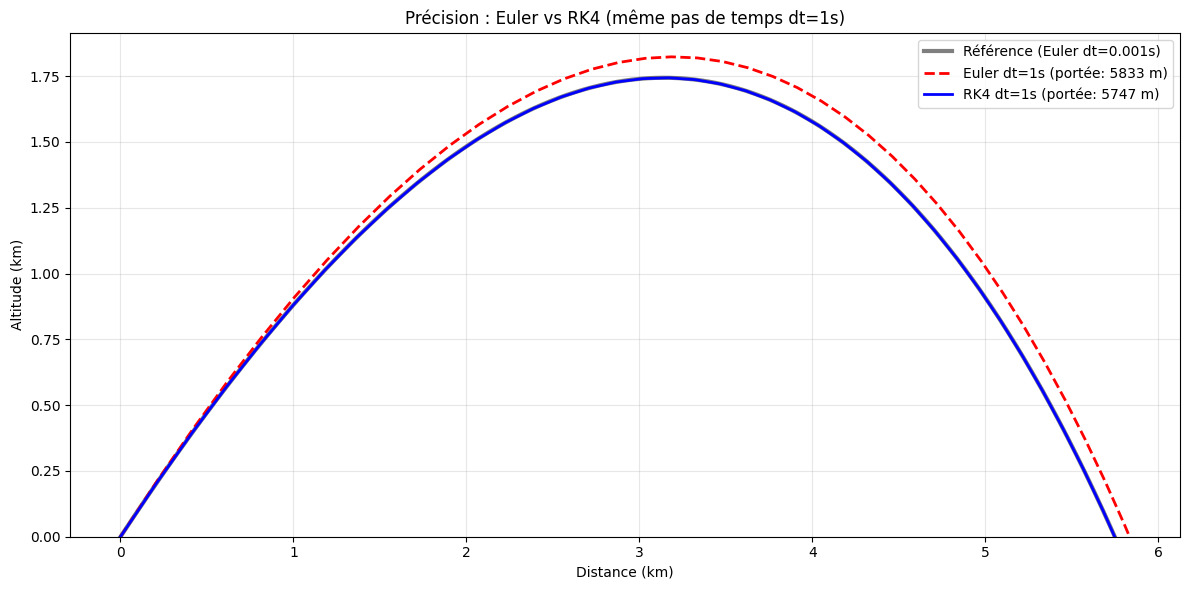

In [9]:
params = dict(v0=300, angle_deg=45, masse=100, Cd=0.3, A=0.05)

r_euler = RocketWithDrag(**params)
r_rk4   = RocketRK4(**params)

# Euler avec grand dt (moins précis)
t_e, x_e, y_e, _, _ = r_euler.trajectoire_euler(dt=1.0)

# RK4 avec même dt
t_r, x_r, y_r = r_rk4.trajectoire_rk4(dt=1.0)

# Référence : Euler très précis (dt=0.001)
t_ref, x_ref, y_ref, _, _ = r_euler.trajectoire_euler(dt=0.001)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(x_ref/1000, y_ref/1000, 'k-', linewidth=3, 
        label='Référence (Euler dt=0.001s)', alpha=0.5)
ax.plot(x_e/1000, y_e/1000, 'r--', linewidth=2, 
        label=f'Euler dt=1s (portée: {x_e[-1]:.0f} m)')
ax.plot(x_r/1000, y_r/1000, 'b-', linewidth=2,
        label=f'RK4 dt=1s (portée: {x_r[-1]:.0f} m)')

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Précision : Euler vs RK4 (même pas de temps dt=1s)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('euler_vs_rk4.png', dpi=150)
plt.show()

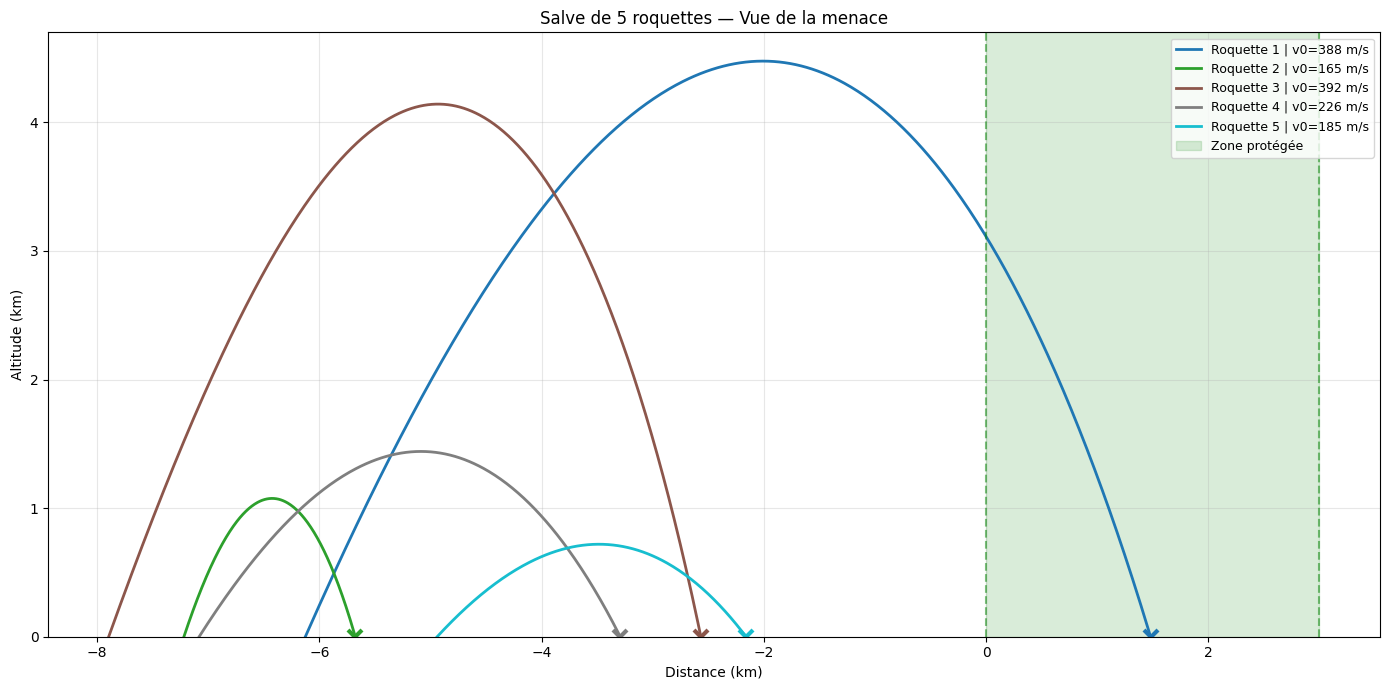

In [10]:
class ThreatGenerator:
    """
    Génère des roquettes aléatoires depuis des zones de lancement.
    """
    
    def __init__(self, seed=42):
        np.random.seed(seed)  # pour reproduire les mêmes résultats
        
        # Zone de lancement (position de l'ennemi)
        self.launch_zone_x = (-8000, -3000)  # mètres
        self.launch_zone_y = (0, 0)           # au niveau du sol
        
        # Plages de paramètres réalistes
        self.v0_range     = (150, 400)   # m/s
        self.angle_range  = (30, 75)     # degrés
        self.masse_range  = (50, 200)    # kg
        self.Cd_range     = (0.2, 0.5)   # coefficient drag
    
    def generer_une_menace(self):
        """Génère une roquette avec des paramètres aléatoires."""
        x0  = np.random.uniform(*self.launch_zone_x)
        v0  = np.random.uniform(*self.v0_range)
        ang = np.random.uniform(*self.angle_range)
        m   = np.random.uniform(*self.masse_range)
        Cd  = np.random.uniform(*self.Cd_range)
        
        return RocketRK4(v0=v0, angle_deg=ang, 
                         masse=m, Cd=Cd, x0=x0, y0=0)
    
    def generer_salve(self, n=5):
        """Génère une salve de n roquettes."""
        return [self.generer_une_menace() for _ in range(n)]


# Test
gen = ThreatGenerator(seed=42)
salve = gen.generer_salve(n=5)

fig, ax = plt.subplots(figsize=(14, 7))

couleurs = plt.cm.tab10(np.linspace(0, 1, len(salve)))

for i, roquette in enumerate(salve):
    t, x, y = roquette.trajectoire_rk4(dt=0.1)
    ax.plot(x/1000, y/1000, color=couleurs[i], linewidth=2,
            label=f'Roquette {i+1} | v0={roquette.v0:.0f} m/s')
    # Marquer le point d'impact
    ax.plot(x[-1]/1000, 0, 'x', color=couleurs[i], 
            markersize=10, markeredgewidth=3)

# Zone protégée
zone_x = [0, 3]
ax.axvspan(0, 3, alpha=0.15, color='green', label='Zone protégée')
ax.axvline(x=0, color='green', linestyle='--', alpha=0.5)
ax.axvline(x=3, color='green', linestyle='--', alpha=0.5)

ax.set_xlabel('Distance (km)')
ax.set_ylabel('Altitude (km)')
ax.set_title('Salve de 5 roquettes — Vue de la menace')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.savefig('salve_menaces.png', dpi=150)
plt.show()

## Extension 3D — Trajectoire balistique en trois dimensions
Ajout de l'azimut (direction horizontale) pour simuler des roquettes
venant de différentes directions.

In [11]:
class Rocket3D:
    """
    Roquette en 3D avec résistance de l'air.
    Intégration RK4.
    
    Axes :
    - x : distance (vers la zone protégée)
    - y : altitude
    - z : latéral (gauche/droite)
    """
    
    def __init__(self, v0, theta_deg, phi_deg, masse=100,
                 Cd=0.3, A=0.05, x0=0, y0=0, z0=0):
        """
        Paramètres :
        - v0        : vitesse initiale (m/s)
        - theta_deg : angle d'élévation (degrés)
        - phi_deg   : azimut (degrés) - 0=droit, 90=gauche
        - masse     : masse (kg)
        - Cd        : coefficient de traînée
        - A         : section transversale (m²)
        - x0,y0,z0  : position initiale
        """
        self.v0 = v0
        self.theta = np.radians(theta_deg)
        self.phi = np.radians(phi_deg)
        self.masse = masse
        self.Cd = Cd
        self.A = A
        self.x0, self.y0, self.z0 = x0, y0, z0
        
        self.g = 9.81
        self.rho = 1.225
        
        # Décomposition 3D de la vitesse initiale
        self.vx0 = v0 * np.cos(self.theta) * np.cos(self.phi)
        self.vy0 = v0 * np.sin(self.theta)
        self.vz0 = v0 * np.cos(self.theta) * np.sin(self.phi)
    
    def _derivees(self, state):
        """
        state = [x, y, z, vx, vy, vz]
        Retourne les dérivées [vx, vy, vz, ax, ay, az]
        """
        x, y, z, vx, vy, vz = state
        
        v = np.sqrt(vx**2 + vy**2 + vz**2)
        
        if v > 0:
            k = 0.5 * self.rho * self.Cd * self.A / self.masse
            ax = -k * v * vx
            ay = -self.g - k * v * vy
            az = -k * v * vz
        else:
            ax = 0
            ay = -self.g
            az = 0
        
        return np.array([vx, vy, vz, ax, ay, az])
    
    def trajectoire_rk4(self, dt=0.1):
        """Calcule la trajectoire 3D par RK4."""
        t_list = []
        x_list, y_list, z_list = [], [], []
        
        t = 0
        state = np.array([self.x0, self.y0, self.z0,
                          self.vx0, self.vy0, self.vz0])
        
        while True:
            t_list.append(t)
            x_list.append(state[0])
            y_list.append(state[1])
            z_list.append(state[2])
            
            # RK4
            k1 = self._derivees(state)
            k2 = self._derivees(state + dt/2 * k1)
            k3 = self._derivees(state + dt/2 * k2)
            k4 = self._derivees(state + dt * k3)
            
            new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
            t += dt
            
            # Interception au sol
            if new_state[1] < 0 and state[1] >= 0:
                frac = state[1] / (state[1] - new_state[1])
                t_list.append(t - dt + frac * dt)
                x_list.append(state[0] + frac * (new_state[0] - state[0]))
                y_list.append(0.0)
                z_list.append(state[2] + frac * (new_state[2] - state[2]))
                break
            
            state = new_state
        
        return (np.array(t_list), np.array(x_list),
                np.array(y_list), np.array(z_list))
    
    def infos(self):
        print(f"=== Roquette 3D ===")
        print(f"Vitesse initiale : {self.v0} m/s")
        print(f"Elevation        : {np.degrees(self.theta):.1f} deg")
        print(f"Azimut           : {np.degrees(self.phi):.1f} deg")
        print(f"Vx0={self.vx0:.1f}  Vy0={self.vy0:.1f}  Vz0={self.vz0:.1f} m/s")

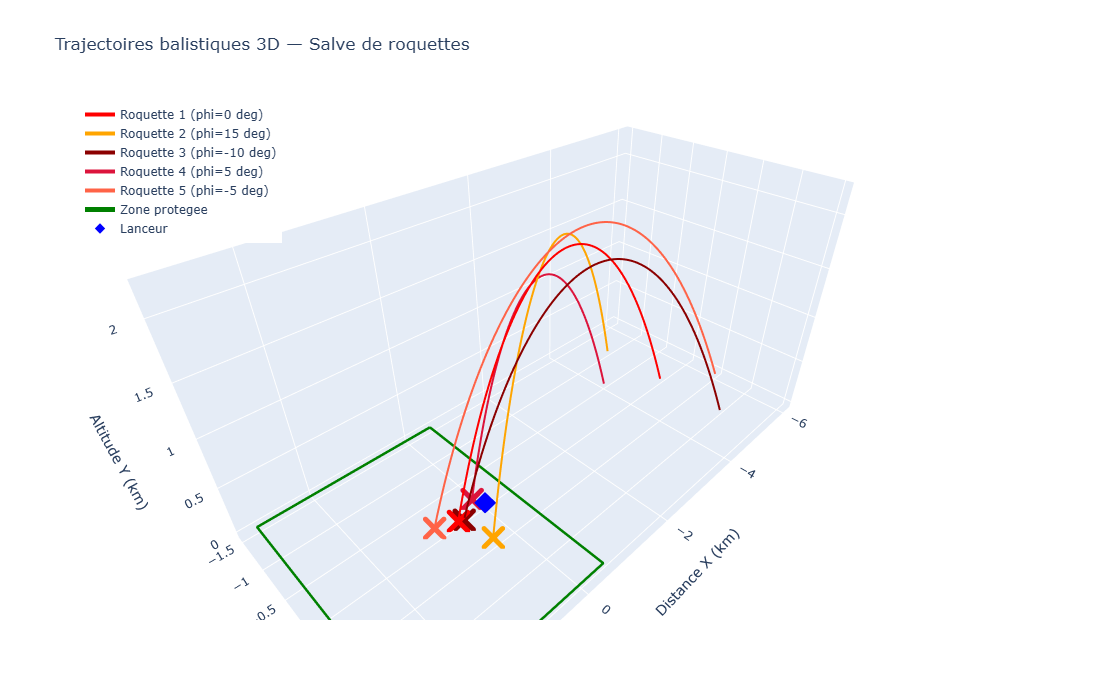

In [12]:
import plotly.graph_objects as go

# Créer plusieurs roquettes avec des azimuts différents
roquettes_3d = [
    Rocket3D(v0=300, theta_deg=50, phi_deg=0, Cd=0.3, x0=-5000, z0=0),
    Rocket3D(v0=300, theta_deg=50, phi_deg=15, Cd=0.3, x0=-5000, z0=-1000),
    Rocket3D(v0=300, theta_deg=50, phi_deg=-10, Cd=0.3, x0=-5000, z0=1000),
    Rocket3D(v0=250, theta_deg=55, phi_deg=5, Cd=0.3, x0=-4000, z0=-500),
    Rocket3D(v0=350, theta_deg=45, phi_deg=-5, Cd=0.3, x0=-6000, z0=500),
]

fig = go.Figure()

couleurs = ['red', 'orange', 'darkred', 'crimson', 'tomato']

for i, r in enumerate(roquettes_3d):
    t, x, y, z = r.trajectoire_rk4(dt=0.1)
    
    fig.add_trace(go.Scatter3d(
        x=x/1000, y=z/1000, z=y/1000,
        mode='lines',
        line=dict(color=couleurs[i], width=4),
        name=f'Roquette {i+1} (phi={np.degrees(r.phi):.0f} deg)'
    ))
    
    # Point d'impact
    fig.add_trace(go.Scatter3d(
        x=[x[-1]/1000], y=[z[-1]/1000], z=[0],
        mode='markers',
        marker=dict(size=6, color=couleurs[i], symbol='x'),
        showlegend=False
    ))

# Zone protégée (rectangle au sol)
zone_x = np.array([-0.5, 3, 3, -0.5, -0.5])
zone_z = np.array([-1.5, -1.5, 1.5, 1.5, -1.5])
zone_y = np.zeros(5)

fig.add_trace(go.Scatter3d(
    x=zone_x, y=zone_z, z=zone_y,
    mode='lines',
    line=dict(color='green', width=5),
    name='Zone protegee'
))

# Lanceur
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    marker=dict(size=8, color='blue', symbol='diamond'),
    name='Lanceur'
))

fig.update_layout(
    title='Trajectoires balistiques 3D — Salve de roquettes',
    scene=dict(
        xaxis_title='Distance X (km)',
        yaxis_title='Lateral Z (km)',
        zaxis_title='Altitude Y (km)',
        aspectmode='manual',
        aspectratio=dict(x=2, y=1, z=1)
    ),
    width=900,
    height=700,
    legend=dict(x=0, y=1)
)

fig.show()

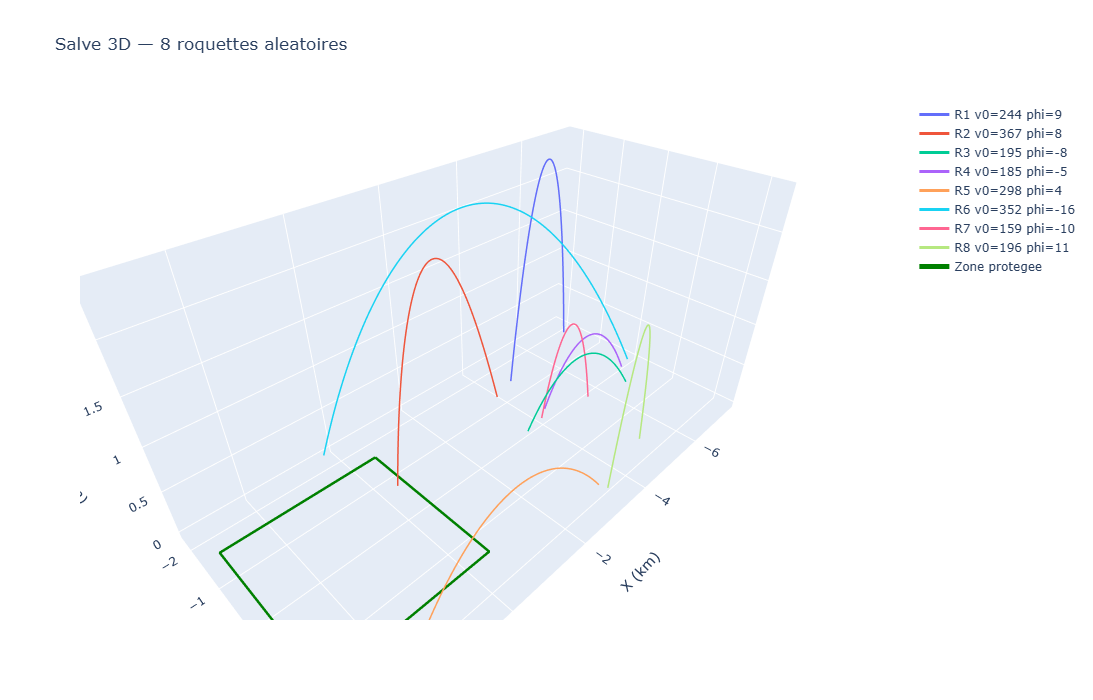

In [14]:
class ThreatGenerator3D:
    """Génère des roquettes 3D aléatoires."""
    
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.v0_range = (150, 400)
        self.theta_range = (30, 75)
        self.phi_range = (-20, 20)     # azimut limité
        self.masse_range = (50, 200)
        self.Cd_range = (0.2, 0.5)
        self.x0_range = (-8000, -3000)
        self.z0_range = (-2000, 2000)
    
    def generer_une_menace(self):
        return Rocket3D(
            v0=np.random.uniform(*self.v0_range),
            theta_deg=np.random.uniform(*self.theta_range),
            phi_deg=np.random.uniform(*self.phi_range),
            masse=np.random.uniform(*self.masse_range),
            Cd=np.random.uniform(*self.Cd_range),
            x0=np.random.uniform(*self.x0_range),
            z0=np.random.uniform(*self.z0_range)
        )
    
    def generer_salve(self, n=5):
        return [self.generer_une_menace() for _ in range(n)]

# Test
gen3d = ThreatGenerator3D(seed=42)
salve3d = gen3d.generer_salve(n=8)

fig = go.Figure()

for i, r in enumerate(salve3d):
    t, x, y, z = r.trajectoire_rk4(dt=0.1)
    
    fig.add_trace(go.Scatter3d(
        x=x/1000, y=z/1000, z=y/1000,
        mode='lines',
        line=dict(width=3),
        name=f'R{i+1} v0={r.v0:.0f} phi={np.degrees(r.phi):.0f}'
    ))

# Zone protégée
fig.add_trace(go.Scatter3d(
    x=zone_x, y=zone_z, z=zone_y,
    mode='lines',
    line=dict(color='green', width=5),
    name='Zone protegee'
))

fig.update_layout(
    title='Salve 3D — 8 roquettes aleatoires',
    scene=dict(
        xaxis_title='X (km)', yaxis_title='Z (km)', zaxis_title='Altitude (km)',
        aspectmode='manual', aspectratio=dict(x=2, y=1, z=1)
    ),
    width=900, height=700
)
fig.show()

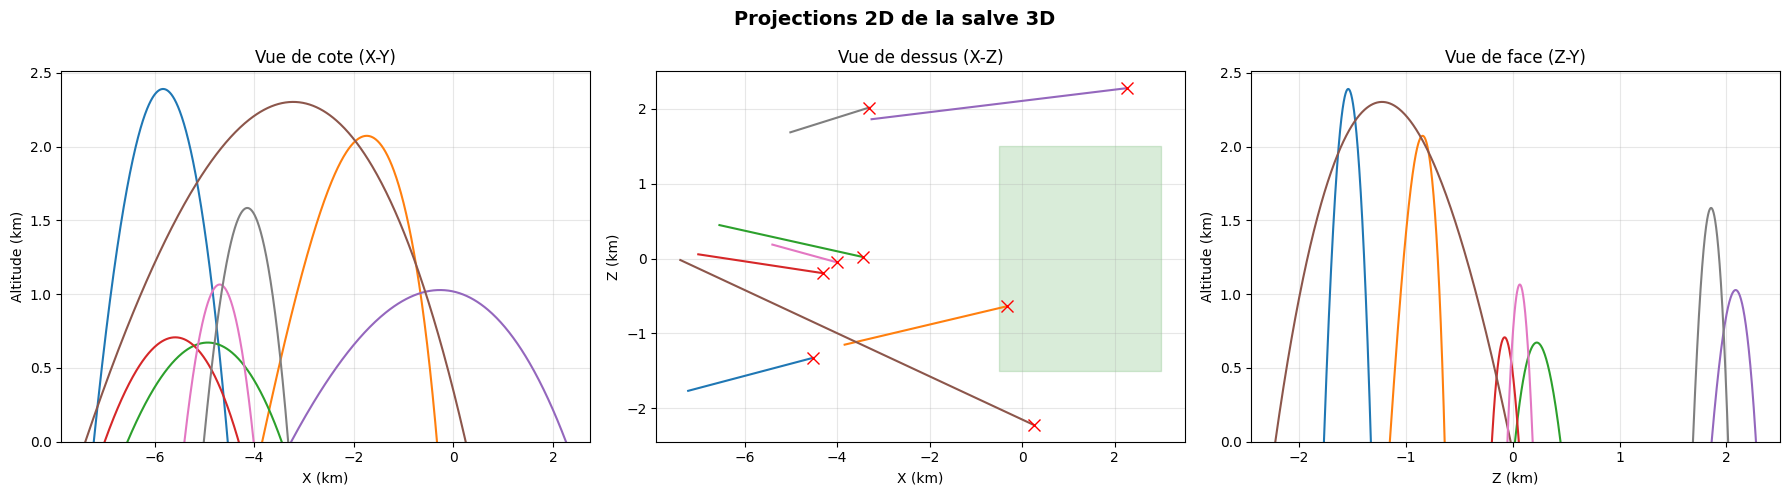

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for r in salve3d:
    t, x, y, z = r.trajectoire_rk4(dt=0.1)
    
    # Vue de côté (x, y)
    axes[0].plot(x/1000, y/1000, linewidth=1.5)
    
    # Vue de dessus (x, z)
    axes[1].plot(x/1000, z/1000, linewidth=1.5)
    axes[1].plot(x[-1]/1000, z[-1]/1000, 'rx', markersize=8)
    
    # Vue de face (z, y)
    axes[2].plot(z/1000, y/1000, linewidth=1.5)

# Zone protégée
axes[1].fill_between([-0.5, 3], [-1.5, -1.5], [1.5, 1.5], 
                      alpha=0.15, color='green', label='Zone')

axes[0].set_xlabel('X (km)'); axes[0].set_ylabel('Altitude (km)')
axes[0].set_title('Vue de cote (X-Y)'); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

axes[1].set_xlabel('X (km)'); axes[1].set_ylabel('Z (km)')
axes[1].set_title('Vue de dessus (X-Z)'); axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Z (km)'); axes[2].set_ylabel('Altitude (km)')
axes[2].set_title('Vue de face (Z-Y)'); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(bottom=0)

plt.suptitle('Projections 2D de la salve 3D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
%%writefile ../src/simulation/rocket.py
import numpy as np

class Rocket:

    
    def __init__(self, v0, angle_deg, x0=0, y0=0):
        
        self.v0 = v0
        self.angle = np.radians(angle_deg)  
        self.x0 = x0
        self.y0 = y0
        self.g = 9.81  
        
        # vitesse initiale
        self.vx0 = v0 * np.cos(self.angle) 
        self.vy0 = v0 * np.sin(self.angle)  
    
    def temps_de_vol(self):
        """Calcule la durée totale du vol jusqu'à l'impact au sol."""
        return (2 * self.vy0) / self.g
    
    def portee(self):
        """Calcule la distance horizontale totale (portée)."""
        return (self.v0**2 * np.sin(2 * self.angle)) / self.g
    
    def hauteur_max(self):
        """Calcule l'altitude maximale atteinte."""
        return (self.vy0**2) / (2 * self.g)
    
    def position(self, t):
        """
        Calcule la position (x, y) à l'instant t.
        Retourne None si la roquette a déjà touché le sol.
        """
        x = self.x0 + self.vx0 * t
        y = self.y0 + self.vy0 * t - 0.5 * self.g * t**2
        
        # La roquette ne va pas sous le sol
        if y < 0:
            return None
        return x, y
    
    def trajectoire_complete(self, dt=0.1):
        """
        Génère tous les points de la trajectoire.
        dt = pas de temps en secondes (plus petit = plus précis)
        """
        T = self.temps_de_vol()
        
        # Créer un tableau de temps de 0 à T par pas de dt
        t_array = np.arange(0, T, dt)
        
        # Calculer x et y pour chaque instant
        x_array = self.x0 + self.vx0 * t_array
        y_array = self.y0 + self.vy0 * t_array - 0.5 * self.g * t_array**2
        
        # Garder uniquement les points où y >= 0
        masque = y_array >= 0
        
        return t_array[masque], x_array[masque], y_array[masque]
    
    def vitesse(self, t):
        """Calcule la vitesse (vx, vy) à l'instant t."""
        vx = self.vx0  # constante
        vy = self.vy0 - self.g * t
        return vx, vy
    
    def infos(self):
        """Affiche un résumé des caractéristiques de la roquette."""
        print(f"=== Roquette ===")
        print(f"Vitesse initiale  : {self.v0} m/s")
        print(f"Angle de tir      : {np.degrees(self.angle):.1f}°")
        print(f"Vitesse X initiale: {self.vx0:.2f} m/s")
        print(f"Vitesse Y initiale: {self.vy0:.2f} m/s")
        print(f"Temps de vol      : {self.temps_de_vol():.2f} s")
        print(f"Portée            : {self.portee():.2f} m")
        print(f"Hauteur maximale  : {self.hauteur_max():.2f} m")



class RocketWithDrag:
    """
    Roquette avec résistance de l'air.
    Utilise la méthode d'Euler pour intégration numérique.
    """
    
    def __init__(self, v0, angle_deg, masse=100, 
                 Cd=0.3, A=0.05, x0=0, y0=0):
        self.v0 = v0
        self.angle = np.radians(angle_deg)
        self.masse = masse
        self.Cd = Cd
        self.A = A
        self.x0 = x0
        self.y0 = y0
        
        self.g = 9.81
        self.rho = 1.225
        
        self.vx0 = v0 * np.cos(self.angle)
        self.vy0 = v0 * np.sin(self.angle)
    
    def _force_drag(self, vx, vy):
        v = np.sqrt(vx**2 + vy**2)
        if v == 0:
            return 0, 0
        F_drag = 0.5 * self.rho * self.Cd * self.A * v**2
        F_drag_x = -F_drag * (vx / v)
        F_drag_y = -F_drag * (vy / v)
        return F_drag_x, F_drag_y
    
    def trajectoire_euler(self, dt=0.01):
        t_list, x_list, y_list = [], [], []
        vx_list, vy_list = [], []
        
        t = 0
        x, y = self.x0, self.y0
        vx, vy = self.vx0, self.vy0
        
        while True:
            t_list.append(t)
            x_list.append(x)
            y_list.append(y)
            vx_list.append(vx)
            vy_list.append(vy)
            
            Fdx, Fdy = self._force_drag(vx, vy)
            ax = Fdx / self.masse
            ay = -self.g + Fdy / self.masse
            
            new_vx = vx + ax * dt
            new_vy = vy + ay * dt
            new_x = x + vx * dt
            new_y = y + vy * dt
            
            # Si y passe en dessous de 0 → interpoler
            if new_y < 0 and y >= 0:
                frac = y / (y - new_y)
                t_list.append(t + frac * dt)
                x_list.append(x + frac * (new_x - x))
                y_list.append(0.0)
                vx_list.append(vx + frac * (new_vx - vx))
                vy_list.append(vy + frac * (new_vy - vy))
                break
            
            vx, vy = new_vx, new_vy
            x, y = new_x, new_y
            t += dt
        
        return (np.array(t_list), np.array(x_list), 
                np.array(y_list), np.array(vx_list), np.array(vy_list))



class RocketRK4(RocketWithDrag):
    
    
    def _derivees(self, state):
        x, y, vx, vy = state
        Fdx, Fdy = self._force_drag(vx, vy)
        ax = Fdx / self.masse
        ay = -self.g + Fdy / self.masse
        return np.array([vx, vy, ax, ay])
    
    def trajectoire_rk4(self, dt=0.1):
        t_list, x_list, y_list = [], [], []
        
        t = 0
        state = np.array([self.x0, self.y0, self.vx0, self.vy0])
        
        while True:
            t_list.append(t)
            x_list.append(state[0])
            y_list.append(state[1])
            
            k1 = self._derivees(state)
            k2 = self._derivees(state + dt/2 * k1)
            k3 = self._derivees(state + dt/2 * k2)
            k4 = self._derivees(state + dt * k3)
            
            new_state = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
            t += dt
            
            # Si y passe en dessous de 0 → interpoler
            if new_state[1] < 0 and state[1] >= 0:
                frac = state[1] / (state[1] - new_state[1])
                x_impact = state[0] + frac * (new_state[0] - state[0])
                t_impact = t - dt + frac * dt
                
                t_list.append(t_impact)
                x_list.append(x_impact)
                y_list.append(0.0)
                break
            
            state = new_state
        
        return np.array(t_list), np.array(x_list), np.array(y_list)



class ThreatGenerator:
    """
    Génère des roquettes aléatoires depuis des zones de lancement.
    """
    
    def __init__(self, seed=42):
        np.random.seed(seed)  # pour reproduire les mêmes résultats
        
        # Zone de lancement (position de l'ennemi)
        self.launch_zone_x = (-8000, -3000)  # mètres
        self.launch_zone_y = (0, 0)           # au niveau du sol
        
        # Plages de paramètres réalistes
        self.v0_range     = (150, 400)   # m/s
        self.angle_range  = (30, 75)     # degrés
        self.masse_range  = (50, 200)    # kg
        self.Cd_range     = (0.2, 0.5)   # coefficient drag
    
    def generer_une_menace(self):
        """Génère une roquette avec des paramètres aléatoires."""
        x0  = np.random.uniform(*self.launch_zone_x)
        v0  = np.random.uniform(*self.v0_range)
        ang = np.random.uniform(*self.angle_range)
        m   = np.random.uniform(*self.masse_range)
        Cd  = np.random.uniform(*self.Cd_range)
        
        return RocketRK4(v0=v0, angle_deg=ang, 
                         masse=m, Cd=Cd, x0=x0, y0=0)
    
    def generer_salve(self, n=5):
        """Génère une salve de n roquettes."""
        return [self.generer_une_menace() for _ in range(n)]


Overwriting ../src/simulation/rocket.py


In [18]:
%%writefile ../src/simulation/rocket3d.py
import numpy as np

class Rocket3D:
    def __init__(self, v0, theta_deg, phi_deg, masse=100,
                 Cd=0.3, A=0.05, x0=0, y0=0, z0=0):
        self.v0 = v0
        self.theta = np.radians(theta_deg)
        self.phi = np.radians(phi_deg)
        self.masse = masse
        self.Cd = Cd
        self.A = A
        self.x0, self.y0, self.z0 = x0, y0, z0
        self.g = 9.81
        self.rho = 1.225
        self.vx0 = v0 * np.cos(self.theta) * np.cos(self.phi)
        self.vy0 = v0 * np.sin(self.theta)
        self.vz0 = v0 * np.cos(self.theta) * np.sin(self.phi)
    
    def _derivees(self, state):
        x, y, z, vx, vy, vz = state
        v = np.sqrt(vx**2 + vy**2 + vz**2)
        if v > 0:
            k = 0.5 * self.rho * self.Cd * self.A / self.masse
            ax = -k * v * vx
            ay = -self.g - k * v * vy
            az = -k * v * vz
        else:
            ax, ay, az = 0, -self.g, 0
        return np.array([vx, vy, vz, ax, ay, az])
    
    def trajectoire_rk4(self, dt=0.1):
        t_l, x_l, y_l, z_l = [], [], [], []
        t = 0
        state = np.array([self.x0, self.y0, self.z0, self.vx0, self.vy0, self.vz0])
        while True:
            t_l.append(t); x_l.append(state[0]); y_l.append(state[1]); z_l.append(state[2])
            k1 = self._derivees(state)
            k2 = self._derivees(state + dt/2 * k1)
            k3 = self._derivees(state + dt/2 * k2)
            k4 = self._derivees(state + dt * k3)
            ns = state + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)
            t += dt
            if ns[1] < 0 and state[1] >= 0:
                f = state[1] / (state[1] - ns[1])
                t_l.append(t - dt + f * dt)
                x_l.append(state[0] + f * (ns[0] - state[0]))
                y_l.append(0.0)
                z_l.append(state[2] + f * (ns[2] - state[2]))
                break
            state = ns
        return np.array(t_l), np.array(x_l), np.array(y_l), np.array(z_l)


class ThreatGenerator3D:
    def __init__(self, seed=42):
        np.random.seed(seed)
        self.v0_range = (150, 400)
        self.theta_range = (30, 75)
        self.phi_range = (-20, 20)
        self.masse_range = (50, 200)
        self.Cd_range = (0.2, 0.5)
        self.x0_range = (-8000, -3000)
        self.z0_range = (-2000, 2000)
    
    def generer_une_menace(self):
        return Rocket3D(
            v0=np.random.uniform(*self.v0_range),
            theta_deg=np.random.uniform(*self.theta_range),
            phi_deg=np.random.uniform(*self.phi_range),
            masse=np.random.uniform(*self.masse_range),
            Cd=np.random.uniform(*self.Cd_range),
            x0=np.random.uniform(*self.x0_range),
            z0=np.random.uniform(*self.z0_range)
        )
    
    def generer_salve(self, n=5):
        return [self.generer_une_menace() for _ in range(n)]

Overwriting ../src/simulation/rocket3d.py
